download data: https://www.nyc.gov/site/tlc/about/about-tlc.page

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pickle

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

import mlflow
from mlflow.tracking import MlflowClient

#### MLflow UI

MLflow provides a web-based User Interface (UI) to visualize and compare all your experiment runs. It makes it easier to analyze metrics, parameters, models, and artifacts in one place.

#### RUNNING MLflow UI LOCALLY

To launch the MLflow UI locally, run the following command:

> `mlflow ui --backend-store-uri sqlite:///mlflow.db`

This command starts a local server and opens the MLflow dashboard at **`http://127.0.0.1:5000`**

---

In addition to the UI, an interface that is introduced in the course and used to automate processes is the Tracking API. Initialized through:

In [2]:
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000/"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("nyc-new-brand-experiment_first")

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [3]:
df = pd.read_parquet('data/yellow_tripdata_2023-01.parquet')

df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [4]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

7.658559638448584

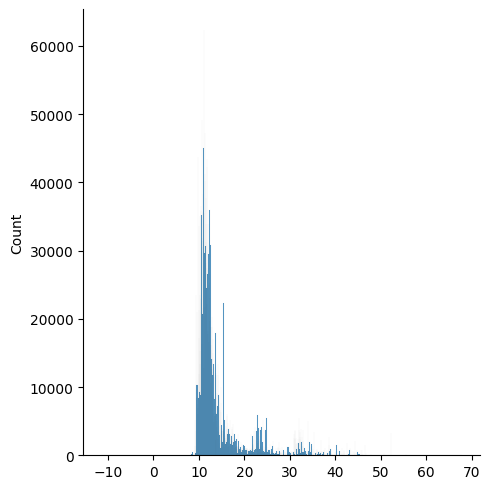

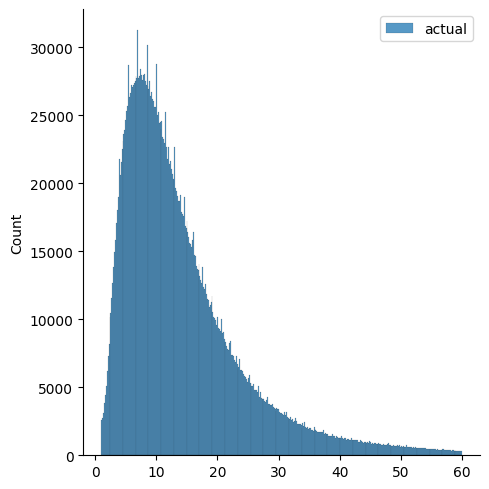

In [5]:
sns.displot(y_pred, label='prediction')
sns.displot(y_train, label='actual')

plt.legend()

In [6]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [7]:
df_train = read_dataframe('data/yellow_tripdata_2023-01.parquet')
df_val = read_dataframe('data/yellow_tripdata_2023-02.parquet')

In [8]:
len(df_train), len(df_val)

(3009173, 2855951)

In [9]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [10]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [11]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

5.247526252493592

In [13]:
with open('model/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [ ]:
with mlflow.start_run():
    
    mlflow.set_tag("developer", "niltonpegass")
    mlflow.log_param("tain data path","./data/green_tripdata_2021-01.parquet")
    mlflow.log_param("val data path", "./data/green_tripdata_2021-02.parquet")
    
    alpha = 0.01
    mlflow.log_param("alpha", alpha)

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred, squared=False)
    mlflow.log_metric("rmse", rmse)

2026/05/27 06:06:38 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



🏃 View run debonair-dove-641 at: http://127.0.0.1:5000/#/experiments/2/runs/32db8c9d611444ad8478cdeb6139039b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2


TypeError: got an unexpected keyword argument 'squared'